In [1]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder")
import utils as ut
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import json

In [2]:
#################
### Load Data ###
#################
settings_file_path = "/home/sc.uni-leipzig.de/fl53wumy/llaae_new/DistributionalPrincipalAutoencoder/joint_training/dpa_train_settings.json"
with open(settings_file_path, 'r') as file:
    settings = json.load(file)
  
# Save to a new file for logging
#with open(f"used_settings.json", "w") as f:
#    json.dump(settings, f, indent=4)

# Load temperature data
ds = xr.open_dataset(settings['dataset_trefht'])
print("Dataset:", settings['dataset_trefht'])
ds

Dataset: /work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/europe_10percent_masked_stacked_TREFHT_JJA.nc


<xarray.Dataset> Size: 2GB
Dimensions:  (lat: 32, lon: 32, time: 476900)
Coordinates:
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * time     (time) object 4MB 1850-06-02 00:00:00 ... 2100-08-31 00:00:00
Data variables:
    TREFHT   (lat, lon, time) float32 2GB ...

In [3]:
##########################
### create dummy array ###
##########################

da = xr.DataArray(
    np.zeros((32, 32)),
    dims=("lat", "lon"),
    coords={"lat": ds.lat, "lon": ds.lon},
    name="zeros",
)
da

<xarray.DataArray 'zeros' (lat: 32, lon: 32)> Size: 8kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5

In [4]:
# temperature domain 
lw=0.5

# Germany
lat_south_ger = 48.534031
lat_north_ger = 53.246073
lon_west_ger = 6.25
lon_east_ger = 15

boundary_south_lon_ger = np.linspace(lon_west_ger, lon_east_ger, 100)
boundary_south_lat_ger =np.full(100, lat_south_ger)

boundary_east_lat_ger = np.linspace(lat_south_ger, lat_north_ger, 100)
boundary_east_lon_ger = np.full(100, lon_east_ger)

boundary_north_lon_ger = np.linspace(lon_west_ger, lon_east_ger, 100)
boundary_north_lat_ger = np.full(100, lat_north_ger)

boundary_west_lat_ger = np.linspace(lat_south_ger, lat_north_ger, 100)
boundary_west_lon_ger = np.full(100, lon_west_ger)

# France
lat_south_fr = 45
lat_north_fr = 50
lon_west_fr = 0
lon_east_fr = 5

boundary_south_lon_fr = np.linspace(lon_west_fr, lon_east_fr, 100)
boundary_south_lat_fr =np.full(100, lat_south_fr)

boundary_east_lat_fr = np.linspace(lat_south_fr, lat_north_fr, 100)
boundary_east_lon_fr = np.full(100, lon_east_fr)

boundary_north_lon_fr = np.linspace(lon_west_fr, lon_east_fr, 100)
boundary_north_lat_fr = np.full(100, lat_north_fr)

boundary_west_lat_fr = np.linspace(lat_south_fr, lat_north_fr, 100)
boundary_west_lon_fr = np.full(100, lon_west_fr)

# Spain
lat_south_sp = 38
lat_north_sp = 42
lon_west_sp = -8
lon_east_sp = 0

boundary_south_lon_sp = np.linspace(lon_west_sp, lon_east_sp, 100)
boundary_south_lat_sp =np.full(100, lat_south_sp)

boundary_east_lat_sp = np.linspace(lat_south_sp, lat_north_sp, 100)
boundary_east_lon_sp = np.full(100, lon_east_sp)

boundary_north_lon_sp = np.linspace(lon_west_sp, lon_east_sp, 100)
boundary_north_lat_sp = np.full(100, lat_north_sp)

boundary_west_lat_sp = np.linspace(lat_south_sp, lat_north_sp, 100)
boundary_west_lon_sp = np.full(100, lon_west_sp)

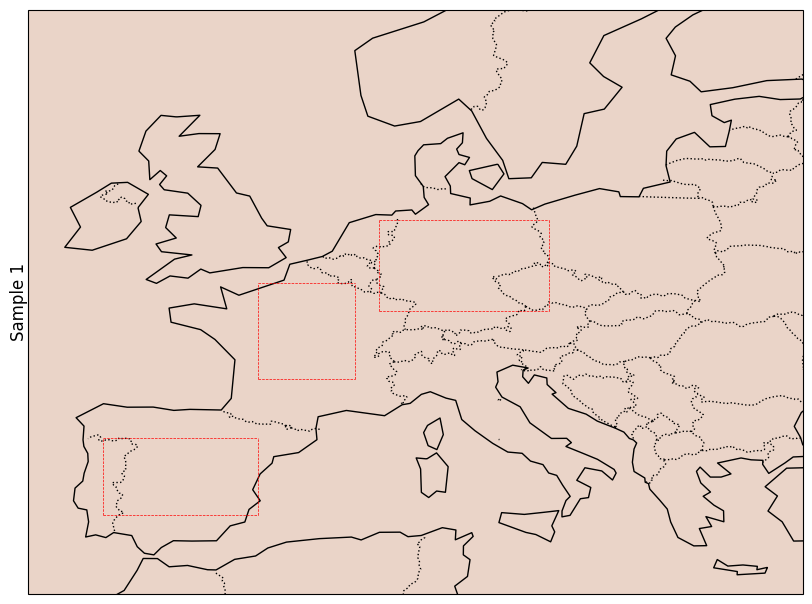

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})
plot = ut.plot_temperature_panel(ax, da, vmax_shared=5, sample_nr = "Sample 1")

# Germany temp box
ax.plot(boundary_west_lon_ger,boundary_west_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_ger,boundary_south_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_ger,boundary_east_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_ger,boundary_north_lat_ger, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

# France temp box
ax.plot(boundary_west_lon_fr,boundary_west_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_fr,boundary_south_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_fr,boundary_east_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_fr,boundary_north_lat_fr, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

# Spain temp box
ax.plot(boundary_west_lon_sp,boundary_west_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_south_lon_sp,boundary_south_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_east_lon_sp,boundary_east_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed')
ax.plot(boundary_north_lon_sp,boundary_north_lat_sp, transform=ccrs.PlateCarree(), color='r', linewidth=lw, linestyle='dashed', label="T")

In [15]:
plot

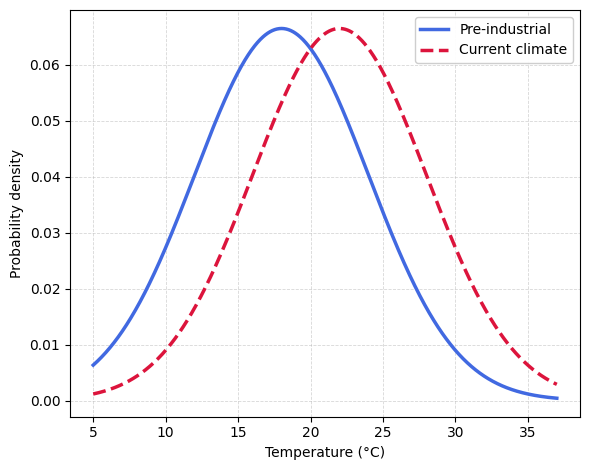

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters (tweak if you like) ---
mu_pre   = 18.0   # mean, pre-industrial (counterfactual)
mu_curr  = 22.0   # mean, current climate
sigma    = 6.0    # common std dev
threshold = 26.0  # extreme-event threshold (°C)

# Domain for temperature axis
x = np.linspace(5, 37, 1000)

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)

y_pre  = normal_pdf(x, mu_pre,  sigma)
y_curr = normal_pdf(x, mu_curr, sigma)

# --- Plot ---
plt.figure(figsize=(6, 4.8))

# PDFs
plt.plot(x, y_pre,  color='royalblue', linewidth=2.5, label='Pre-industrial')
plt.plot(x, y_curr, color='crimson',   linewidth=2.5, linestyle='--', label='Current climate')

# Bold mean indicators
#plt.axvline(mu_pre,  color='royalblue', linewidth=4,  linestyle='-',  label='Mean (pre-industrial)')
#plt.axvline(mu_curr, color='crimson',   linewidth=4,  linestyle='--', label='Mean (current)')

# Threshold
#plt.axvline(threshold, color='black', linewidth=2, linestyle=':', label='Extreme event threshold')

# Shaded tails beyond the threshold
#plt.fill_between(x, y_pre,  0, where=(x >= threshold), color='royalblue', alpha=0.3)
#plt.fill_between(x, y_curr, 0, where=(x >= threshold), color='crimson',   alpha=0.3)

# Cosmetics to match the look
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability density')
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.6, alpha=0.5)
plt.legend(framealpha=0.95)
plt.tight_layout()

# Optional: save to file
# plt.savefig('counterfactual_distribution.png', dpi=200)

plt.show()


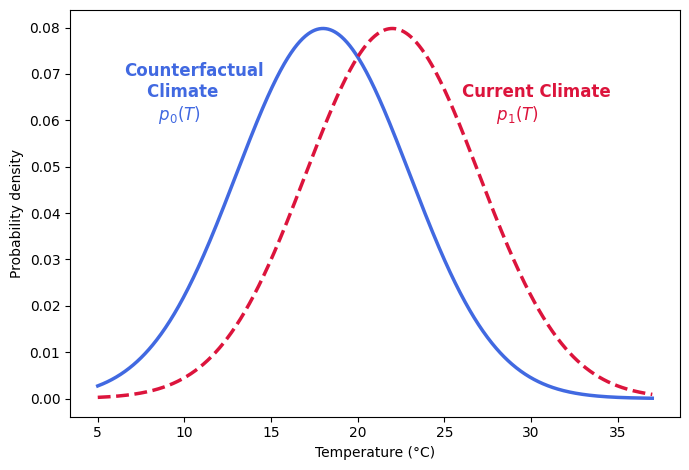

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu_pre   = 18.0
mu_curr  = 22.0
sigma    = 5.0
threshold = 26.0

x = np.linspace(5, 37, 1000)

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)

y_pre  = normal_pdf(x, mu_pre,  sigma)
y_curr = normal_pdf(x, mu_curr, sigma)

# --- Plot ---
plt.figure(figsize=(7, 4.8))

# Curves
plt.plot(x, y_pre,  color='royalblue', linewidth=2.5)
plt.plot(x, y_curr, color='crimson',   linewidth=2.5, linestyle='--')

# Means
#plt.axvline(mu_pre,  color='royalblue', linewidth=4, linestyle='-')
#plt.axvline(mu_curr, color='crimson',   linewidth=4, linestyle='--')

# Threshold
#plt.axvline(threshold, color='black', linewidth=2, linestyle=':')

# Shaded tails
#plt.fill_between(x, y_pre,  0, where=(x >= threshold), color='royalblue', alpha=0.3)
#plt.fill_between(x, y_curr, 0, where=(x >= threshold), color='crimson',   alpha=0.3)

# Labels
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability density')



# Direct annotations in curve colors
plt.text(26, 0.06, "Current Climate\n      "+ r"$p_{1}(T)$", color="crimson", fontsize=12, fontweight="bold")
plt.text(6.5, 0.06, "Counterfactual\n    Climate\n      "+ r"$p_{0}(T)$", color="royalblue", fontsize=12, fontweight="bold")
#plt.text(25, 0.06, r"$p_{1}(T)$", color="crimson", fontsize=12, fontweight="bold")

#plt.text(threshold + 0.2, 0.04, "Extreme threshold", color="black", fontsize=11, rotation=90)

plt.tight_layout()
plt.savefig("risk_cf.pdf")
plt.show()


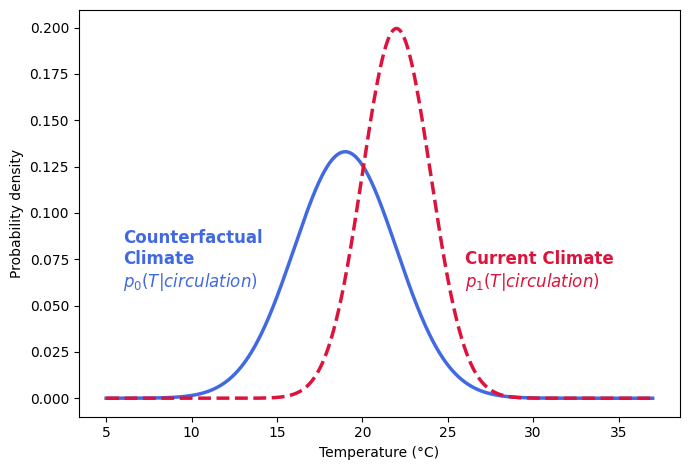

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu_pre   = 19.0
mu_curr  = 22.0
sigma_cf = 3
sigma    = 2.0
threshold = 26.0

x = np.linspace(5, 37, 1000)

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)

y_pre  = normal_pdf(x, mu_pre,  sigma_cf)
y_curr = normal_pdf(x, mu_curr, sigma)

# --- Plot ---
plt.figure(figsize=(7, 4.8))

# Curves
plt.plot(x, y_pre,  color='royalblue', linewidth=2.5)
plt.plot(x, y_curr, color='crimson',   linewidth=2.5, linestyle='--')

# Means
#plt.axvline(mu_pre,  color='royalblue', linewidth=4, linestyle='-')
#plt.axvline(mu_curr, color='crimson',   linewidth=4, linestyle='--')

# Threshold
#plt.axvline(threshold, color='black', linewidth=2, linestyle=':')

# Shaded tails
#plt.fill_between(x, y_pre,  0, where=(x >= threshold), color='royalblue', alpha=0.3)
#plt.fill_between(x, y_curr, 0, where=(x >= threshold), color='crimson',   alpha=0.3)

# Labels
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability density')



# Direct annotations in curve colors
plt.text(26, 0.06, "Current Climate\n"+ r"$p_{1}(T|circulation)$", color="crimson", fontsize=12, fontweight="bold")
plt.text(6.0, 0.06, "Counterfactual\nClimate\n"+ r"$p_{0}(T|circulation)$", color="royalblue", fontsize=12, fontweight="bold")
#plt.text(25, 0.06, r"$p_{1}(T)$", color="crimson", fontsize=12, fontweight="bold")

#plt.text(threshold + 0.2, 0.04, "Extreme threshold", color="black", fontsize=11, rotation=90)

plt.tight_layout()
plt.savefig("storyline_cf.pdf")
plt.show()


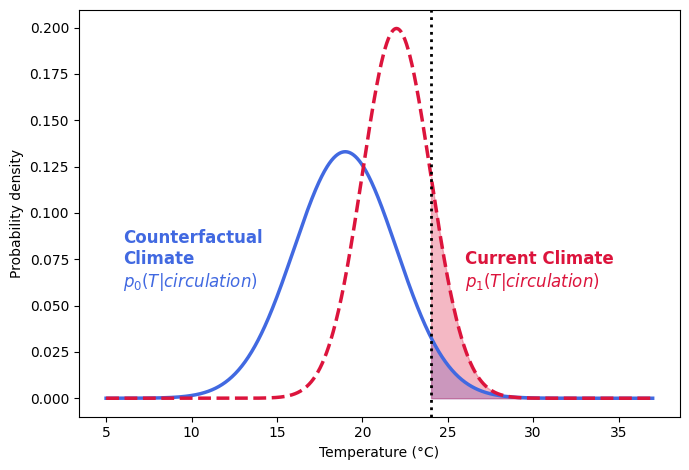

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu_pre   = 19.0
mu_curr  = 22.0
sigma_cf = 3
sigma    = 2.0
threshold = 24.0

x = np.linspace(5, 37, 1000)

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)

y_pre  = normal_pdf(x, mu_pre,  sigma_cf)
y_curr = normal_pdf(x, mu_curr, sigma)

# --- Plot ---
plt.figure(figsize=(7, 4.8))

# Curves
plt.plot(x, y_pre,  color='royalblue', linewidth=2.5)
plt.plot(x, y_curr, color='crimson',   linewidth=2.5, linestyle='--')

# Means
#plt.axvline(mu_pre,  color='royalblue', linewidth=4, linestyle='-')
#plt.axvline(mu_curr, color='crimson',   linewidth=4, linestyle='--')

# Threshold
plt.axvline(threshold, color='black', linewidth=2, linestyle=':')

# Shaded tails
plt.fill_between(x, y_pre,  0, where=(x >= threshold), color='royalblue', alpha=0.3)
plt.fill_between(x, y_curr, 0, where=(x >= threshold), color='crimson',   alpha=0.3)

# Labels
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability density')



# Direct annotations in curve colors
plt.text(26, 0.06, "Current Climate\n"+ r"$p_{1}(T|circulation)$", color="crimson", fontsize=12, fontweight="bold")
plt.text(6.0, 0.06, "Counterfactual\nClimate\n"+ r"$p_{0}(T|circulation)$", color="royalblue", fontsize=12, fontweight="bold")
#plt.text(25, 0.06, r"$p_{1}(T)$", color="crimson", fontsize=12, fontweight="bold")

#plt.text(threshold + 0.2, 0.04, "Extreme threshold", color="black", fontsize=11, rotation=90)

plt.tight_layout()
plt.savefig("storyline_cf_threshold.pdf")
plt.show()


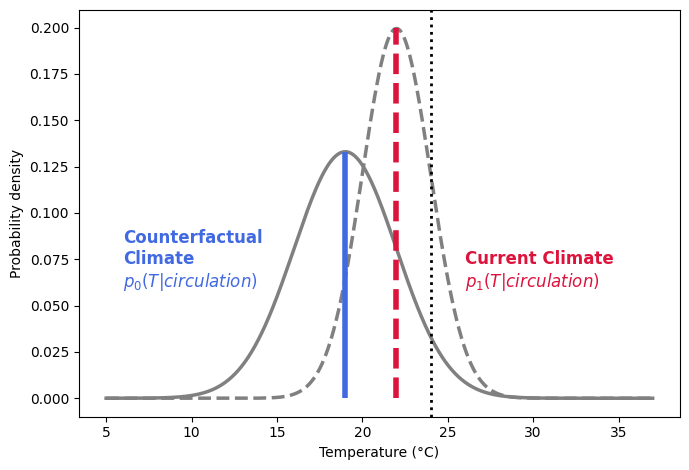

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
mu_pre   = 19.0
mu_curr  = 22.0
sigma_cf = 3
sigma    = 2.0
threshold = 24.0

x = np.linspace(5, 37, 1000)

def normal_pdf(x, mu, sigma):
    return (1.0 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-0.5*((x - mu)/sigma)**2)

y_pre  = normal_pdf(x, mu_pre,  sigma_cf)
y_curr = normal_pdf(x, mu_curr, sigma)

# --- Plot ---
plt.figure(figsize=(7, 4.8))

# Curves
plt.plot(x, y_pre,  color='grey', linewidth=2.5)
plt.plot(x, y_curr, color='grey',   linewidth=2.5, linestyle='--')

# Means – stop at the curve
y_pre_at_mean  = normal_pdf(mu_pre,  mu_pre,  sigma_cf)
y_curr_at_mean = normal_pdf(mu_curr, mu_curr, sigma)

plt.vlines(mu_pre,  0, y_pre_at_mean,  color='royalblue', linewidth=4, linestyle='-')
plt.vlines(mu_curr, 0, y_curr_at_mean, color='crimson',   linewidth=4, linestyle='--')

# Threshold
plt.axvline(threshold, color='black', linewidth=2, linestyle=':')

# Shaded tails
#plt.fill_between(x, y_pre,  0, where=(x >= threshold), color='royalblue', alpha=0.3)
#plt.fill_between(x, y_curr, 0, where=(x >= threshold), color='crimson',   alpha=0.3)

# Labels
plt.xlabel('Temperature (°C)')
plt.ylabel('Probability density')



# Direct annotations in curve colors
plt.text(26, 0.06, "Current Climate\n"+ r"$p_{1}(T|circulation)$", color="crimson", fontsize=12, fontweight="bold")
plt.text(6.0, 0.06, "Counterfactual\nClimate\n"+ r"$p_{0}(T|circulation)$", color="royalblue", fontsize=12, fontweight="bold")
#plt.text(25, 0.06, r"$p_{1}(T)$", color="crimson", fontsize=12, fontweight="bold")

#plt.text(threshold + 0.2, 0.04, "Extreme threshold", color="black", fontsize=11, rotation=90)

plt.tight_layout()
plt.savefig("storyline_cf_threshold_and_mean.pdf")
plt.show()
